In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from umap import UMAP


In [11]:
protein_info = pd.read_csv('../Data/raw/9606.protein.info.v12.0.txt', sep='\t')
protein_info.iloc[:,0] = protein_info.iloc[:,0].str.replace("9606.ENSP00000","")

/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/180960195.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  protein_info.iloc[:,0] = protein_info.iloc[:,0].str.replace("9606.ENSP00000","")


In [12]:
conversion = pd.read_csv('../Data/protein_node_id_conversion.csv')
node_to_idx = dict(zip(conversion["protein_id"], conversion["node_id"]))

In [37]:
# assuming you have the latent_variables_sampled.csv file in the same directory
# The file can be found at https://drive.google.com/file/d/1YhYhG-476Rh3H0F37hB-RqRGuz791c4M/view?usp=drive_link
sampled_latent_representation = pd.read_csv('latent_variables_sampled.csv')
sampled_latent_representation.drop(columns=['Unnamed: 0', 'version'], inplace=True)
sampled_latent_representation.head()

,epoch,node,mu,logstd
0,10,0,"[-0.128, 0.084, -0.031, -0.073, 0.069, 0.045, ...","[-0.765, -0.835, -0.777, -1.075, -1.12, -0.985..."
1,10,1,"[-0.028, -0.09, -0.04, -0.161, -0.002, -0.065,...","[-1.657, -1.999, -1.605, -2.225, -2.58, -2.142..."
2,10,2,"[0.161, -0.045, -0.041, 0.018, -0.152, -0.257,...","[-1.934, -2.124, -1.585, -2.609, -2.94, -2.237..."
3,10,3,"[0.294, -0.088, -0.007, -0.155, -0.077, -0.061...","[-1.214, -1.327, -1.062, -1.551, -1.789, -1.37..."
4,10,4,"[-0.158, 0.172, -0.049, 0.008, 0.085, 0.057, 0...","[-1.229, -1.819, -1.348, -2.063, -2.182, -1.88..."


In [38]:
sampled_latent_representation['mu'] = sampled_latent_representation['mu'].apply(eval)
sampled_latent_representation['logstd'] = sampled_latent_representation['logstd'].apply(eval)

# Convert lists into separate DataFrames
mu_df_sampled = pd.DataFrame(sampled_latent_representation['mu'].to_list())
mu_df_sampled = pd.concat([sampled_latent_representation[['epoch','node']],mu_df_sampled],axis=1)

### Separation of Housekeeping and Context-Dependent Proteins

In [29]:
# Define keywords for housekeeping proteins
housekeeping_keywords = "ribosome|translation|elongation factor|rrna|ribosomal protein|rna polymerase"

# Select proteins that match the housekeeping criteria
housekeeping_df = protein_info[protein_info['annotation'].str.lower().str.contains(housekeeping_keywords, regex=True)]
print(f"Number of housekeeping proteins: {housekeeping_df.shape[0]}")

Number of housekeeping proteins: 1008


In [30]:
housekeeping_df["#string_protein_id"] = housekeeping_df["#string_protein_id"].astype(int)
housekeeping_df["node_id"] = housekeeping_df["#string_protein_id"].map(node_to_idx)
housekeeping_df.dropna(inplace=True)
housekeeping_df.shape[0]

/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/2170458787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housekeeping_df["#string_protein_id"] = housekeeping_df["#string_protein_id"].astype(int)
/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/2170458787.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housekeeping_df["node_id"] = housekeeping_df["#string_protein_id"].map(node_to_idx)
/Users/gxy/miniforge3/envs/dsc80/lib/python3.8/site-packages/pandas/util/_decorato

617

In [31]:
# Define keywords for context-dependent proteins
context_dependent_keywords = "cytokine|chemokine|interleukin|interferon|complement|granzyme|perforin"

# Select proteins matching context-dependent criteria
context_dependent_df = protein_info[protein_info['annotation'].str.lower().str.contains(context_dependent_keywords, regex=True)]
print(f"Number of context-dependent proteins: {context_dependent_df.shape[0]}")

Number of context-dependent proteins: 824


In [32]:
context_dependent_df["#string_protein_id"]=context_dependent_df["#string_protein_id"].astype(int)

context_dependent_df["node_id"] = context_dependent_df["#string_protein_id"].map(node_to_idx)
context_dependent_df.dropna(inplace=True)
context_dependent_df.shape[0]

/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/1349290148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  context_dependent_df["#string_protein_id"]=context_dependent_df["#string_protein_id"].astype(int)
/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/1349290148.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  context_dependent_df["node_id"] = context_dependent_df["#string_protein_id"].map(node_to_idx)


457

In [42]:
housekeeping_nodes = housekeeping_df['node_id'].tolist()
context_dependent_nodes = context_dependent_df['node_id'].tolist()

selected_proteins = housekeeping_nodes + context_dependent_nodes
labels = ["Housekeeping"] * len(housekeeping_nodes) + ["Context-Dependent"] * len(context_dependent_nodes)

/Users/gxy/miniforge3/envs/dsc80/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/gxy/miniforge3/envs/dsc80/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/gxy/miniforge3/envs/dsc80/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/gxy/miniforge3/envs/dsc80/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting ran

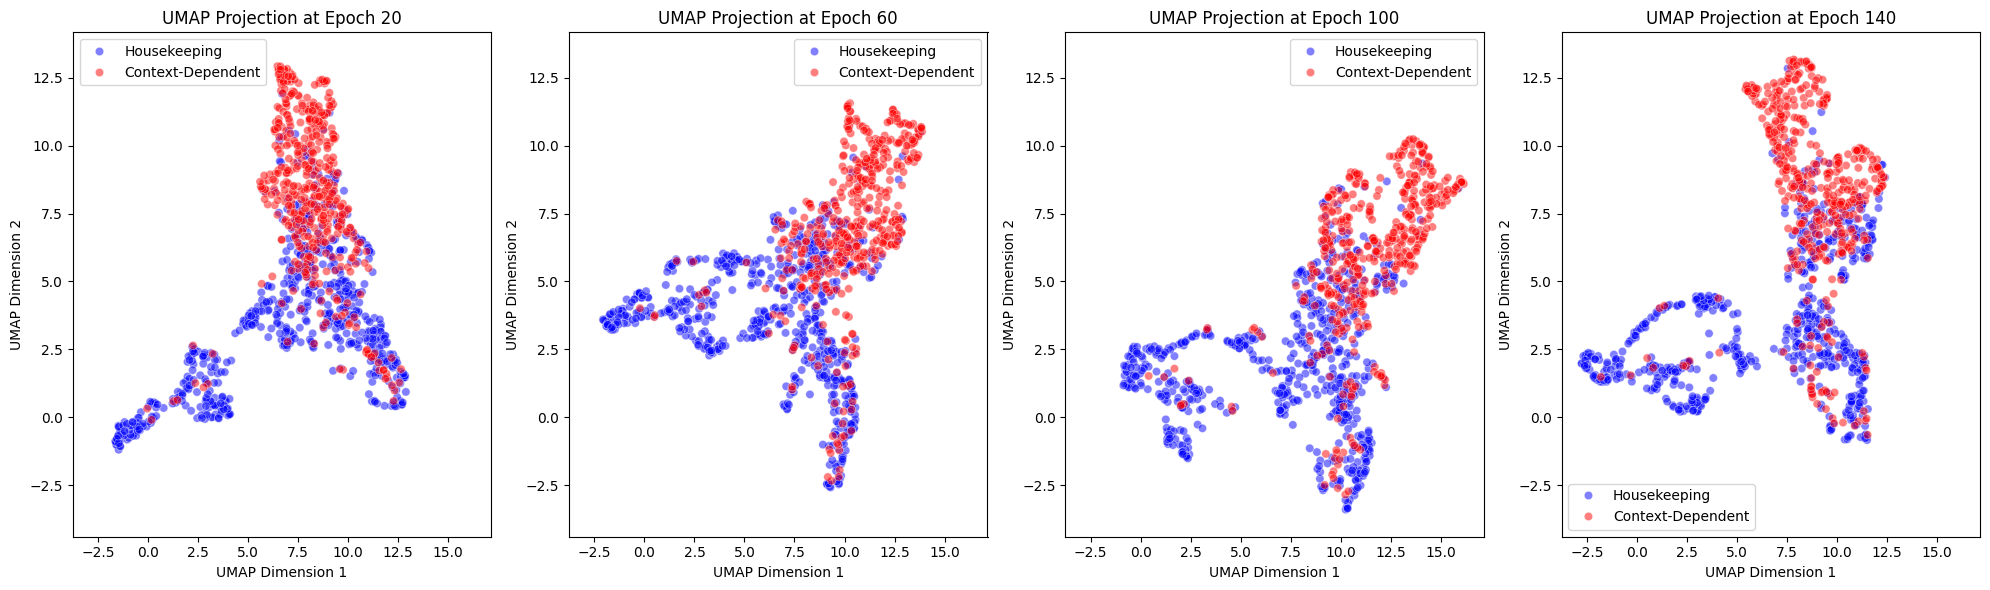

In [43]:
# Define epochs to visualize
epoch_selected = [20, 60, 100, 140]

# Create a 1x4 subplot grid
fig, axes = plt.subplots(1,4, figsize=(20, 6))
axes = axes.flatten() 

umap_embeddings = []

for epoch in epoch_selected:
    mu_epoch = mu_df_sampled[mu_df_sampled['epoch'] == epoch]
    mu_epoch.set_index('node', inplace=True)

    selected_mu_df = mu_epoch.loc[selected_proteins]

    umap_model = UMAP(n_neighbors=10, min_dist=0.3, n_components=2, random_state=42)
    umap_embedding = umap_model.fit_transform(selected_mu_df)

    umap_embeddings.append(umap_embedding)

all_embeddings = np.vstack(umap_embeddings)
x_min, x_max = all_embeddings[:, 0].min(), all_embeddings[:, 0].max()
y_min, y_max = all_embeddings[:, 1].min(), all_embeddings[:, 1].max()

for i, (epoch, umap_embedding) in enumerate(zip(epoch_selected, umap_embeddings)):
    ax = axes[i]
    sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=labels, palette=["blue", "red"], alpha=0.5, ax=ax)

    ax.set_xlim(x_min-1, x_max+1)
    ax.set_ylim(y_min-1, y_max+1)
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.set_title(f"UMAP Projection at Epoch {epoch}")

plt.tight_layout()
plt.show()

### Convergence of Highly Connected and Sparsely Connected Proteins

Idea of tracking convergence: $\text{var}(\mu)_t - \text{var}(\mu)_{\text{final}}$ vs. epoch t

In [44]:
filtered_ppi_data=pd.read_csv('../Data/filtered_PPI.csv')

In [45]:
degree_counts = pd.concat([
    filtered_ppi_data['protein1'], 
    filtered_ppi_data['protein2']
]).value_counts().reset_index()
degree_counts.columns = ['protein_id', 'num_connections']

mean_strengths = pd.concat([
    filtered_ppi_data.groupby('protein1')['combined_score'].mean(),
    filtered_ppi_data.groupby('protein2')['combined_score'].mean()
]).groupby(level=0).mean().reset_index()
mean_strengths.columns = ['protein_id', 'mean_connection_strength']

protein_connectivity = degree_counts.merge(mean_strengths, on='protein_id')

In [48]:
protein_connectivity['protein_id'] = protein_connectivity['protein_id'].str.replace("9606.ENSP00000","")

/var/folders/rl/hnl6k6053sxb72xb666_fj5r0000gn/T/ipykernel_28335/3729558400.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  protein_connectivity['protein_id'] = protein_connectivity['protein_id'].str.replace("9606.ENSP00000","")


In [49]:
protein_connectivity['protein_id'] = protein_connectivity['protein_id'].astype(int)
protein_connectivity['node_id'] = protein_connectivity['protein_id'].map(node_to_idx)

print(f"Number of Nodes: {protein_connectivity['node_id'].notna().sum()}")

num_node_link = 50
most_linked = protein_connectivity.dropna().iloc[:num_node_link]
least_linked = protein_connectivity.dropna().iloc[-num_node_link:]

most_linked_nodes = list(most_linked['node_id'].astype(int).values)
least_linked_nodes = list(least_linked['node_id'].astype(int).values)

Number of Nodes: 9466


In [51]:
sampled_links_mu = mu_df_sampled[mu_df_sampled['node'].isin(most_linked_nodes+least_linked_nodes)].set_index('node')
sampled_links_mu['var'] = np.var(sampled_links_mu.iloc[:, 1:], axis=1)

final_var = sampled_links_mu[sampled_links_mu['epoch'] == 150]['var']
sampled_links_mu_pivot = sampled_links_mu.pivot_table(index='node', columns='epoch', values='var', aggfunc='mean')

In [52]:
sampled_links_mu_pivot_subtracted = sampled_links_mu_pivot.sub(final_var, axis=0)
sampled_links_mu_pivot_subtracted.head()

epoch,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150
node,,,,,,,,,,,,,,,
35,-0.252729,-0.152518,0.177070,-0.095405,0.160154,0.028721,0.060335,0.029443,-0.080232,0.042475,-0.046254,0.000711,-0.028037,-0.013402,0.0
265,-0.001592,0.019343,0.028446,-0.012184,0.006036,0.000373,-0.012287,-0.005541,-0.005229,-0.005427,0.008893,-0.002832,-0.004292,0.000437,0.0
496,-0.067038,-0.027428,0.168576,0.093168,0.065553,-0.015901,-0.027126,-0.011003,-0.042216,0.011571,-0.014433,-0.046170,0.056859,0.006477,0.0
829,-0.087057,-0.074953,-0.048471,-0.056232,-0.031487,-0.027629,-0.033653,-0.035508,-0.034353,-0.031028,-0.021333,0.013247,-0.003301,-0.010455,0.0
955,0.019239,0.049929,0.003711,0.037450,0.020271,0.004400,0.028259,0.022970,0.024276,0.016018,0.025536,0.034145,0.020700,0.053046,0.0


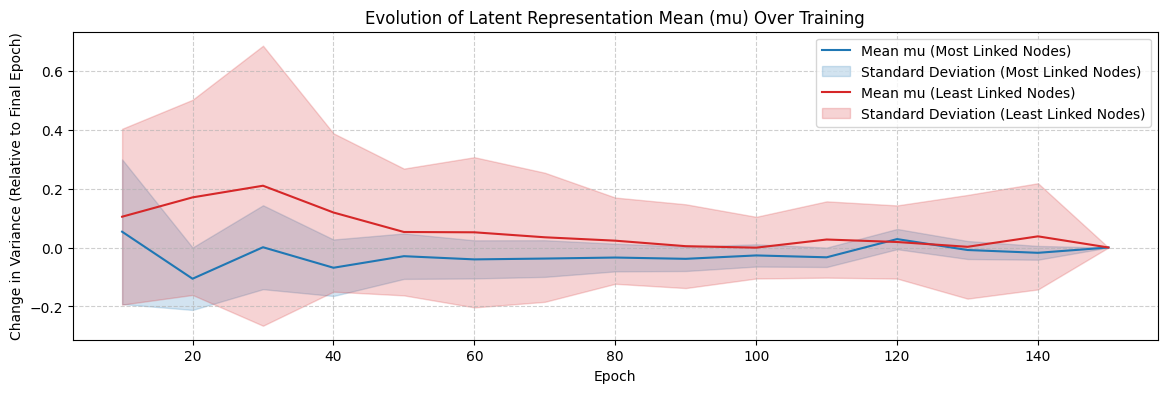

In [54]:
sampled_links_mu_pivot_subtracted_most = sampled_links_mu_pivot_subtracted.loc[most_linked_nodes]
sampled_links_mu_pivot_subtracted_least = sampled_links_mu_pivot_subtracted.loc[least_linked_nodes]

mean_values_most = sampled_links_mu_pivot_subtracted_most.mean(axis=0)  
std_values_most = sampled_links_mu_pivot_subtracted_most.std(axis=0)    
mean_values_least = sampled_links_mu_pivot_subtracted_least.mean(axis=0) 
std_values_least = sampled_links_mu_pivot_subtracted_least.std(axis=0)

epochs = mean_values_most.index.astype(int) 

plt.figure(figsize=(14, 4))

# Plot mean values with standard deviation as shaded region
plt.plot(epochs, mean_values_most, color="tab:blue", label="Mean mu (Most Linked Nodes)")
plt.fill_between(epochs, mean_values_most - std_values_most, mean_values_most + std_values_most, 
                 color="tab:blue", alpha=0.2, label="Standard Deviation (Most Linked Nodes)")
plt.plot(epochs, mean_values_least, color="tab:red", label="Mean mu (Least Linked Nodes)")
plt.fill_between(epochs, mean_values_least - std_values_least, mean_values_least + std_values_least, 
                 color="tab:red", alpha=0.2, label="Standard Deviation (Least Linked Nodes)")

plt.xlabel("Epoch")
plt.ylabel("Change in Variance (Relative to Final Epoch)")
plt.title("Evolution of Latent Representation Mean (mu) Over Training")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()